In [24]:
import numpy as np
import os
import pandas as pd
from data_downloading.loader import CountryData
from models.classic_LC import LeeCarterModel
import matplotlib.pyplot as plt
import seaborn as sns
from config import plot_configuration
from evaluation.evaluator import MortalityEvaluator

import matplotlib.patches as patches
from matplotlib import colormaps

viridis = colormaps["magma"]
colors = plt.cm.magma(np.linspace(0.95, 0.15, 30))

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
uk_data = CountryData(country_hmd_code="GBRTENW")
uk_data.load_data(1950, 2020, maximum_age=90)
uk_data_train, uk_data_test = uk_data.mx.split_by_year(2010, overlap=False)
lc_model_uk = LeeCarterModel(uk_data_train, "Female").fit()

Total years: 71
Training dataset: 61 (85.9 %)
Testing dataset: 10 (14.1 %) 


In [39]:
mortality_evaluation = MortalityEvaluator(lc_model_uk, uk_data_test, 50000)

In [48]:
mortality_evaluation.calculate_error("median", "MASE").sel(Year=1)

KeyError: "not all values found in index 'Year'. Try setting the `method` keyword argument (example: method='nearest')."

In [41]:
mortality_evaluation.calculate_error("median", "MAE")

0.0008429251962148708

In [42]:
mortality_evaluation.calculate_error("median", "RMSE")

0.14904425466012186

In [43]:
print(mortality_evaluation.calculate_error("median", "MASE", 2012))
print(mortality_evaluation.calculate_error("median", "MAE", 2012))
print(mortality_evaluation.calculate_error("median", "RMSE", 2012))

0.8462345452612363
0.0007860381313469152
0.14848412009293346


In [23]:
mortality_evaluation.predicted_data.sel(Year=slice(2012, None)).Year

<xarray.DataArray 'Year' (Year: 9)> Size: 72B
array([2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020])
Coordinates:
  * Year     (Year) int64 72B 2012 2013 2014 2015 2016 2017 2018 2019 2020

<Axes: xlabel='Age', ylabel='log_val'>

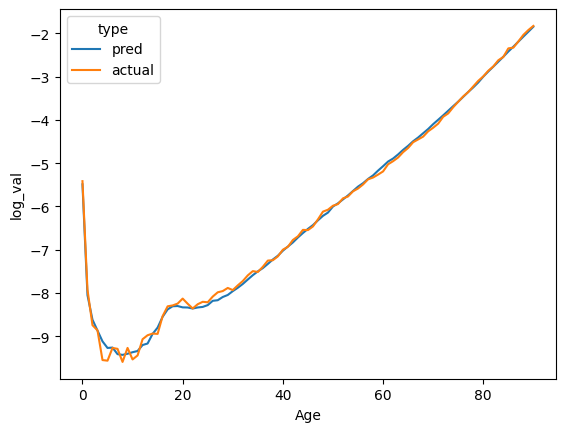

In [97]:
predicted_mx = np.log(
    lc_model_uk.predict_historical()
    .sel(Year=2005)
    .to_dataframe(name="log_val")
    .drop(["Year"], axis=1)
).assign(type="pred")

actual_mx = np.log(
    lc_model_uk.wide_matrix
    .sel(Year=2005)
    .to_dataframe(name="log_val")
    .drop(["Year"], axis=1)
).assign(type="actual")

combined_mx = pd.concat([predicted_mx, actual_mx]).reset_index()

sns.lineplot(combined_mx, x="Age", y="log_val", hue="type")

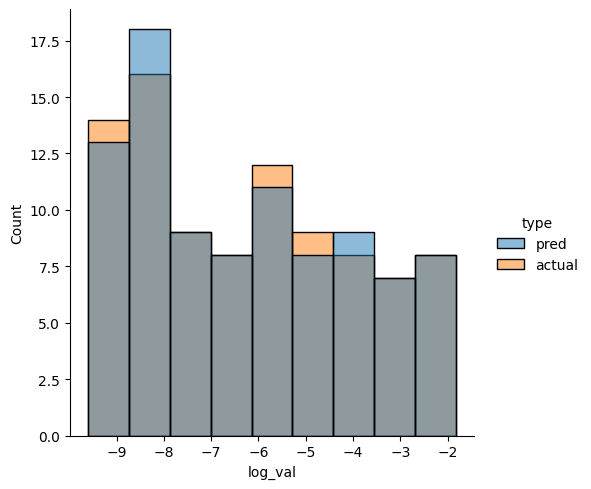

In [98]:
sns.displot(combined_mx, x="log_val", hue="type")

In [6]:
mortality_evaluation.calculate_residuals("median")

AttributeError: 'MortalityEvaluator' object has no attribute 'calculate_residuals'

-----

In [43]:
steps = 20
mx_tensor = lc_model_uk.predict(steps, 100000)

In [29]:
low = np.percentile(mx_tensor, 2.5, axis=2)
mid = np.percentile(mx_tensor, 50, axis=2)
high = np.percentile(mx_tensor, 97.5, axis=2)

In [30]:
age = 0

data = pd.DataFrame({
    "x": np.arange(1950, 2020 + steps + 1, 1),
    "y": np.concatenate([lc_model_uk.matrix.loc[age, :], mid[age, :]], axis = 0)
})

In [31]:
ci_data = pd.DataFrame({
    "x": np.arange(2021, 2020 + steps + 1, 1),
    "low": low[age, :],
    "high": high[age, :]
})

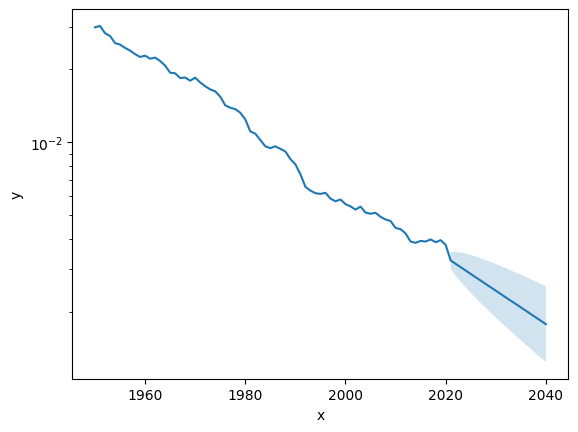

In [46]:
ax = sns.lineplot(data=data, x="x", y="y")
plt.fill_between(ci_data.x, ci_data.low, ci_data.high, alpha=0.2)
#ax.set_xbound(2000, 2040)
#ax.set_ybound(0, 0.01)
ax.set_yscale('log')
plt.show()

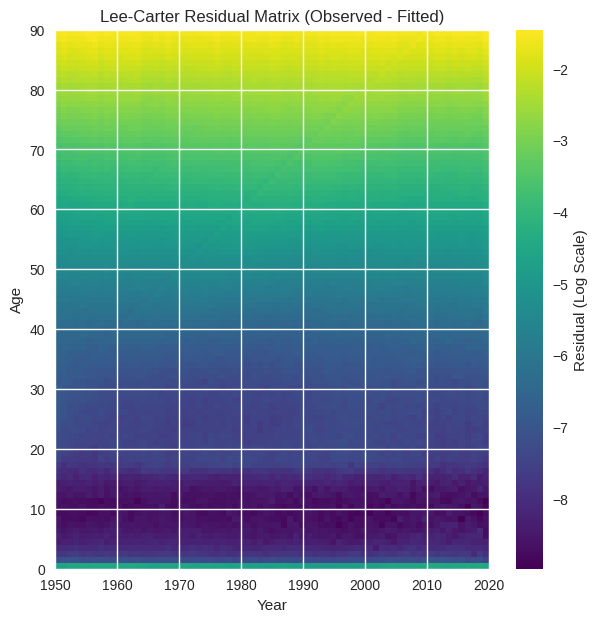

In [201]:
residuals = log_mx - modelled_log_mx
fig, ax = plt.subplots(figsize=(7,7))
im = ax.imshow(
    residuals,
    cmap="viridis",
    aspect="auto",
    origin="lower",
    extent=[residuals.columns.min(), residuals.columns.max(), 
            residuals.index.min(), residuals.index.max()]
)

fig.colorbar(im, ax=ax, label='Residual (Log Scale)')
ax.set_title('Lee-Carter Residual Matrix (Observed - Fitted)')
ax.set_xlabel('Year')
ax.set_ylabel('Age')

plt.show()

In [203]:
r_squared = (s[0]**2) / (np.sum(s**2))
r_squared

np.float64(0.9535890484823908)